In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

In [41]:
CLEAN_TMDB_FILE_PATH = "../datasets/clean/tmdb-movies/TMDB_movie_dataset_v11.csv"
CLEAN_MOVIELENS_RATINGS_PATH = "../datasets/clean/ml-32m/ratings.csv"

ML_API_TF_IDF_MATRIX_PATH = "../../ml-api/model/tf_idf_matrix.pkl"


tmdb_og = pd.read_csv(CLEAN_TMDB_FILE_PATH)
ratings_og = pd.read_csv(CLEAN_MOVIELENS_RATINGS_PATH)

In [42]:
tmdb = tmdb_og
ratings = ratings_og

In [43]:
movie_stats = ratings.groupby("tmdbId").agg(
    avg=("rating", "mean"),
    count=("rating", "count")
)
good_movies = set(movie_stats[movie_stats["count"] >= 0].index)
tmdb_ids = set(tmdb["id"])
valid_movie_ids = good_movies.intersection(tmdb_ids)
ratings = ratings[ratings["tmdbId"].isin(valid_movie_ids)].copy()
tmdb = tmdb[tmdb["id"].isin(valid_movie_ids)].copy()

tmdb = tmdb.reset_index(drop=True)
tmdb_id_to_index = pd.Series(tmdb.index, index=tmdb["id"]).to_dict()

ratings_glob_mean = 2.5
ratings["rating"] = ratings["rating"] - ratings_glob_mean

In [44]:
# počet hodnocení pro každý film
rating_counts = ratings.groupby("tmdbId").size().reset_index(name="rating_count")

# výběr jen potřebných sloupců z tmdb
movies_df = tmdb[["id", "title", "popularity"]].copy()

# merge s počtem hodnocení
movies_df = movies_df.merge(
    rating_counts,
    left_on="id",
    right_on="tmdbId",
    how="left"
)

# odstranění pomocného sloupce
movies_df = movies_df.drop(columns=["tmdbId"])

# případně NaN -> 0
movies_df["rating_count"] = movies_df["rating_count"].fillna(0).astype(int)

movies_df.head()

,id,title,popularity,rating_count
0,27205,Inception,83.952,57931
1,157336,Interstellar,140.241,37157
2,155,The Dark Knight,130.643,59334
3,19995,Avatar,79.932,35043
4,24428,The Avengers,98.082,26315


In [45]:
from pathlib import Path
import json
import re
import pandas as pd

# -----------------------------
# připravení lookup dictionary
# -----------------------------

movie_lookup = movies_df.set_index("id").to_dict(orient="index")

processed_logs = []

logs_folder = "./cinematch_logs"

json_files = list(Path(logs_folder).glob("*.json"))

movie_json_pattern = r'\{.*?\}'

# -----------------------------
# helper funkce
# -----------------------------

def replace_movie(movie_obj):
    """
    Vrátí redukovaná data filmu z movies_df.
    """
    movie_id = movie_obj.get("id")

    if movie_id in movie_lookup:
        return {
            "id": movie_id,
            "title": movie_lookup[movie_id]["title"],
            "popularity": movie_lookup[movie_id]["popularity"],
            "rating_count": movie_lookup[movie_id]["rating_count"]
        }

    return {
        "id": movie_id,
        "title": movie_obj.get("title")
    }


def try_parse_json(text):
    try:
        return json.loads(text)
    except:
        return None


# -----------------------------
# processing logů
# -----------------------------

for file_path in json_files:
    with open(file_path, "r", encoding="utf-8") as f:
        logs = json.load(f)

    processed_file_logs = []

    for entry in logs:

        new_entry = entry.copy()

        # -------------------------
        # ACTION
        # -------------------------

        action = entry.get("action")

        if action:
            parsed = try_parse_json(action)

            # pokud action není čistý json, zkus najít movie objekty
            if parsed is None:

                movie_matches = re.findall(r'\{[^{}]*"id"[^{}]*\}', action)

                for match in movie_matches:
                    try:
                        movie_obj = json.loads(match)

                        reduced_movie = replace_movie(movie_obj)

                        action = action.replace(
                            match,
                            json.dumps(reduced_movie, ensure_ascii=False)
                        )

                    except:
                        pass

                new_entry["action"] = action

        # -------------------------
        # RESULT
        # -------------------------

        result = entry.get("result")

        if result:
            parsed_result = try_parse_json(result)

            # pokud result je array filmů
            if isinstance(parsed_result, list):

                reduced_result = []

                for movie in parsed_result:

                    if isinstance(movie, dict) and "id" in movie:
                        reduced_result.append(replace_movie(movie))
                    else:
                        reduced_result.append(movie)

                new_entry["result"] = reduced_result

        processed_file_logs.append(new_entry)

    processed_logs.append({
        "file": file_path.name,
        "logs": processed_file_logs
    })

# ukázka
processed_logs[0]["logs"]

[{'context': '[Recommender Collab]',
  'action': 'LOG AGENT CREATED',
  'result': None},
 {'context': '[Recommender Content]',
  'action': 'LOG AGENT CREATED',
  'result': None},
 {'context': '[Recommender Collab]',
  'action': 'User requested movies. Profile: {"movieRatings":[{"movie":{"id": 120, "title": "The Lord of the Rings: The Fellowship of the Ring", "popularity": 87.037, "rating_count": 73122},"rating":4.75},{"movie":{"id": 121, "title": "The Lord of the Rings: The Two Towers", "popularity": 78.73, "rating_count": 67463},"rating":4.75},{"movie":{"id": 122, "title": "The Lord of the Rings: The Return of the King", "popularity": 99.276, "rating_count": 67449},"rating":4.85},{"movie":{"id": 49051, "title": "The Hobbit: An Unexpected Journey", "popularity": 83.524, "rating_count": 16149},"rating":4.95},{"movie":{"id": 57158, "title": "The Hobbit: The Desolation of Smaug", "popularity": 70.03, "rating_count": 12175},"rating":4.25},{"movie":{"id": 122917, "title": "The Hobbit: The B

In [46]:
import json
import re

sessions = []

current_session = None


# ----------------------------------------
# helpery
# ----------------------------------------

def extract_profile(action_text):

    try:
        match = re.search(r'Profile:\s*(\{.*\})', action_text)

        if not match:
            return None

        return json.loads(match.group(1))

    except:
        return None


def extract_movie(action_text):

    try:
        match = re.search(r'Movie:\s*(\{.*\})', action_text)

        if not match:
            return None

        return json.loads(match.group(1))

    except:
        return None


# ----------------------------------------
# processing
# ----------------------------------------

for file_data in processed_logs:

    logs = file_data["logs"]

    i = 0

    while i < len(logs):

        entry = logs[i]

        context = entry.get("context", "")
        action = entry.get("action", "")
        result = entry.get("result")

        # ----------------------------------------
        # začátek nové session
        # ----------------------------------------

        if (
            "[Recommender Collab]" in context
            and "User requested movies" in action
        ):

            profile = extract_profile(action)["movieRatings"]

            collab_recs = result

            # očekáváme hned další content recommendation
            content_entry = logs[i + 1]

            content_recs = content_entry.get("result")

            current_session = {
                "profile": profile,

                "collab": {
                    "recommendations": collab_recs,
                    "ratings": []
                },

                "content": {
                    "recommendations": content_recs,
                    "ratings": []
                }
            }

            sessions.append(current_session)

            i += 1
            i += 1
            continue

        # ----------------------------------------
        # collab rating
        # ----------------------------------------

        if "User rated movie from recommendation" in action:

            movie = extract_movie(action)

            try:
                rating = float(result)
            except:
                i += 1
                continue

            rating_obj = {
                "movie": movie,
                "rating": rating
            }

            if "Collab" in context:

                if current_session:
                    current_session["collab"]["ratings"].append(
                        rating_obj
                    )

            elif "Content" in context:

                if current_session:
                    current_session["content"]["ratings"].append(
                        rating_obj
                    )

        i += 1

sessions[73]

{'profile': [{'movie': {'id': 269149,
    'title': 'Zootopia',
    'popularity': 98.11,
    'rating_count': 14431},
   'rating': 4.5},
  {'movie': {'id': 675445,
    'title': 'PAW Patrol: The Movie',
    'popularity': 217.613,
    'rating_count': 14},
   'rating': 2},
  {'movie': {'id': 11360,
    'title': 'Dumbo',
    'popularity': 60.157,
    'rating_count': 10545},
   'rating': 2.5},
  {'movie': {'id': 150540,
    'title': 'Inside Out',
    'popularity': 107.292,
    'rating_count': 21483},
   'rating': 3.75},
  {'movie': {'id': 14160,
    'title': 'Up',
    'popularity': 90.968,
    'rating_count': 36382},
   'rating': 4},
  {'movie': {'id': 10681,
    'title': 'WALL·E',
    'popularity': 58.517,
    'rating_count': 39993},
   'rating': 3.3},
  {'movie': {'id': 585,
    'title': 'Monsters, Inc.',
    'popularity': 86.936,
    'rating_count': 46036},
   'rating': 3.7},
  {'movie': {'id': 3170,
    'title': 'Bambi',
    'popularity': 43.491,
    'rating_count': 9448},
   'rating': 4}

In [64]:
import pandas as pd
import numpy as np

rows = []

for session_id, session in enumerate(sessions):

    profile = session["profile"]

    profile_size = len(profile)

    profile_med_rating = np.median([
        x["rating"] for x in profile
    ])

    profile_med_popularity = np.median([
        x["movie"].get("popularity", 0)
        for x in profile
    ])

    profile_med_rating_count = np.median([
        x["movie"].get("rating_count", 0)
        for x in profile
    ])

    for model in ["collab", "content"]:

        recommendations = session[model]["recommendations"]
        ratings = session[model]["ratings"]

        # -----------------------------
        # recommendation stats
        # -----------------------------

        rec_popularities = [
            x.get("popularity", np.nan)
            for x in recommendations
            if "popularity" in x
        ]

        rec_rating_counts = [
            x.get("rating_count", np.nan)
            for x in recommendations
            if "rating_count" in x
        ]

        # -----------------------------
        # user feedback stats
        # -----------------------------

        user_ratings = [
            x["rating"]
            for x in ratings
        ]

        if(session_id == 73): print(user_ratings)

        rows.append({

            # identifiers
            "session_id": session_id,
            "model": model,

            # profile stats
            "profile_size": profile_size,
            "profile_med_rating": profile_med_rating,
            "profile_med_popularity": profile_med_popularity,
            "profile_med_rating_count": profile_med_rating_count,

            # recommendation batch stats
            "num_recommendations": len(recommendations),

            "recommendation_med_popularity":
                np.median(rec_popularities),

            "recommendation_median_popularity":
                np.median(rec_popularities),

            "recommendation_med_rating_count":
                np.median(rec_rating_counts),

            # user feedback
            "num_rated_movies": len(user_ratings),

            "avg_user_rating":
                np.mean(user_ratings)
                if len(user_ratings) > 0 else np.nan,

            "median_user_rating":
                np.median(user_ratings)
                if len(user_ratings) > 0 else np.nan,

            "max_user_rating":
                np.max(user_ratings)
                if len(user_ratings) > 0 else np.nan,

            "success_rate_4":
                np.mean(np.array(user_ratings) >= 4)
                if len(user_ratings) > 0 else np.nan,

            "success_rate_45":
                np.mean(np.array(user_ratings) >= 4.5)
                if len(user_ratings) > 0 else np.nan,
        })

eval_df = pd.DataFrame(rows)

eval_df.head()

[2.5]
[4.0]


,session_id,model,profile_size,profile_med_rating,profile_med_popularity,profile_med_rating_count,num_recommendations,recommendation_med_popularity,recommendation_median_popularity,recommendation_med_rating_count,num_rated_movies,avg_user_rating,median_user_rating,max_user_rating,success_rate_4,success_rate_45
0,0,collab,8,4.75,81.1270,26308.5,30,60.4785,60.4785,26234.5,1,4.75,4.75,4.75,1.0,1.0
1,0,content,8,4.75,81.1270,26308.5,30,70.5350,70.5350,2599.0,1,4.00,4.00,4.00,1.0,0.0
2,1,collab,10,4.75,79.6195,26308.5,30,73.1585,73.1585,30898.0,1,4.90,4.90,4.90,1.0,1.0
3,1,content,10,4.75,79.6195,26308.5,30,69.4030,69.4030,2885.0,0,NaN,NaN,NaN,NaN,NaN
4,2,collab,11,4.75,78.7300,36468.0,30,60.2540,60.2540,34934.0,1,4.80,4.80,4.80,1.0,1.0


In [65]:
eval_df.groupby("model")[
    [
        "median_user_rating",
        "success_rate_4",
        "success_rate_45",
    ]
].mean()

,median_user_rating,success_rate_4,success_rate_45
model,,,
collab,4.198052,0.714286,0.389610
content,3.926339,0.482143,0.196429


In [66]:
profile_bins = [0, 3, 5, 10, 20, 50]

eval_df["profile_group"] = pd.cut(
    eval_df["profile_size"],
    bins=profile_bins
)


eval_df.groupby(["profile_group", "model"])[["median_user_rating", "success_rate_4", "success_rate_45"]].mean().unstack()


median_user_rating           success_rate_4            \
model                     collab   content         collab   content   
profile_group                                                         
(0, 3]                  4.207500  3.610000       0.750000  0.200000   
(3, 5]                  4.027778  4.187500       0.666667  0.625000   
(5, 10]                 4.323214  3.842857       0.714286  0.357143   
(10, 20]                4.236765  4.053846       0.735294  0.615385   
(20, 50]                4.162037  3.864063       0.703704  0.500000   

              success_rate_45            
model                  collab   content  
profile_group                            
(0, 3]               0.250000  0.200000  
(3, 5]               0.388889  0.250000  
(5, 10]              0.500000  0.250000  
(10, 20]             0.382353  0.153846  
(20, 50]             0.388889  0.156250

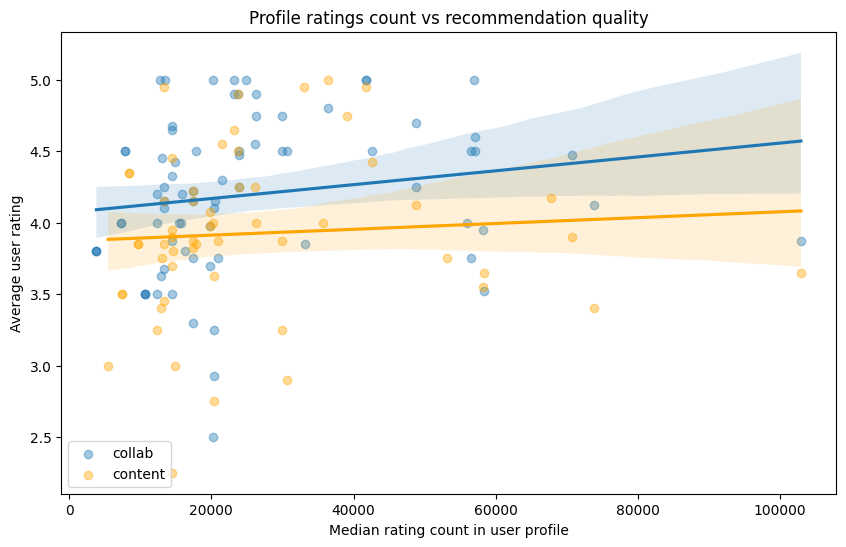

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.regplot(
    data=eval_df[eval_df["model"] == "collab"],
    x="profile_med_rating_count",
    y="median_user_rating",
    scatter_kws={"alpha": 0.4},
    label="collab"
)

sns.regplot(
    data=eval_df[eval_df["model"] == "content"],
    x="profile_med_rating_count",
    y="median_user_rating",
    scatter_kws={"alpha": 0.4},
    label="content",
    color="orange"
)


plt.xlabel("Median rating count in user profile")
plt.ylabel("Average user rating")
plt.title("Profile ratings count vs recommendation quality")

plt.legend()
plt.show()

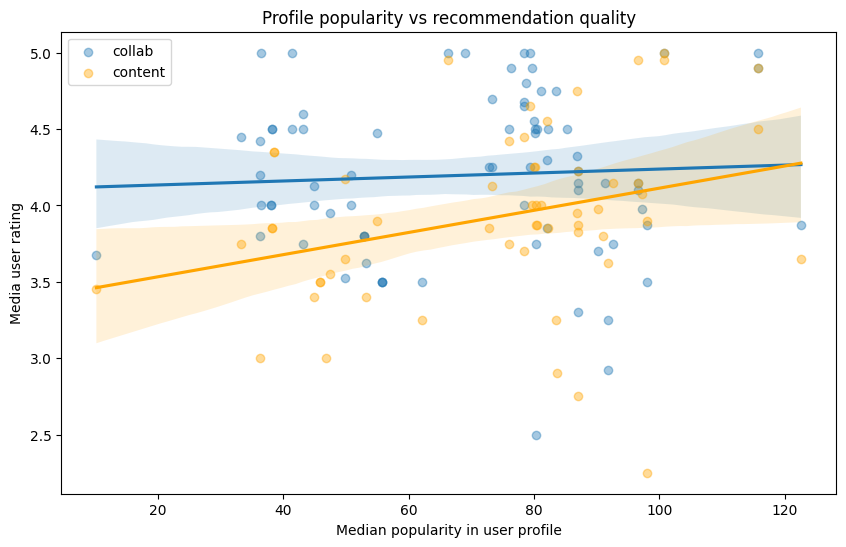

In [77]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=eval_df[eval_df["model"] == "collab"],
    x="profile_med_popularity",
    y="avg_user_rating",
    scatter_kws={"alpha": 0.4},
    label="collab"
)

sns.regplot(
    data=eval_df[eval_df["model"] == "content"],
    x="profile_med_popularity",
    y="avg_user_rating",
    scatter_kws={"alpha": 0.4},
    label="content",
    color="orange"
)


plt.xlabel("Median popularity in user profile")
plt.ylabel("Media user rating")
plt.title("Profile popularity vs recommendation quality")

plt.legend()
plt.show()

In [72]:
eval_df["profile_popularity_group"] = pd.qcut(
    eval_df["profile_med_popularity"],
    q=4,
    labels=[
        "niche",
        "semi-niche",
        "mainstream",
        "very mainstream"
    ]
)

(
    eval_df
    .groupby(
        ["profile_popularity_group", "model"]
    )[
        ["avg_user_rating", "success_rate_4"]
    ]
    .mean()
    .round(3)
)

avg_user_rating  success_rate_4
profile_popularity_group model                                   
niche                    collab             4.279           0.806
                         content            3.750           0.250
semi-niche               collab             4.021           0.583
                         content            3.738           0.292
mainstream               collab             4.433           0.857
                         content            3.986           0.656
very mainstream          collab             4.037           0.600
                         content            4.062           0.550

In [74]:
eval_df["profile_popularity_group"] = pd.qcut(
    eval_df["profile_med_rating_count"],
    q=4,
    labels=[
        "niche",
        "semi-niche",
        "mainstream",
        "very mainstream"
    ]
)

(
    eval_df
    .groupby(
        ["profile_popularity_group", "model"]
    )[
        ["avg_user_rating", "success_rate_4"]
    ]
    .mean()
    .round(3)
)

avg_user_rating  success_rate_4
profile_popularity_group model                                   
niche                    collab             3.971           0.607
                         content            3.706           0.250
semi-niche               collab             4.101           0.714
                         content            3.804           0.382
mainstream               collab             4.297           0.750
                         content            3.957           0.618
very mainstream          collab             4.356           0.750
                         content            4.162           0.571

In [54]:
# 1. Vyfiltrujeme si pouze řádky, kde predikoval Collab model
collab_df = eval_df[eval_df["model"] == "collab"].copy()

# 2. Určíme hranici pro "extrémně vysokou popularitu" 
# (např. top 10 % nejvíce mainstreamových profilů)
hype_threshold = collab_df["profile_avg_popularity"].quantile(0.50)

# 3. Vyfiltrujeme profily s vysokou popularitou, u kterých měl model nízké skóre
failed_hype_profiles = collab_df[
    (collab_df["profile_avg_popularity"] >= hype_threshold) & 
    (collab_df["avg_user_rating"] <= 3.4) # Můžeš zkusit i nižší hranici, např. 2.5
].sort_values("avg_user_rating")

# Vypíšeme si ty nejhorší případy
display(failed_hype_profiles.head())

,session_id,model,profile_size,profile_avg_rating,profile_avg_popularity,profile_avg_rating_count,num_recommendations,recommendation_avg_popularity,recommendation_median_popularity,recommendation_avg_rating_count,num_rated_movies,avg_user_rating,median_user_rating,max_user_rating,success_rate_4,success_rate_45,profile_group,profile_popularity_group
146,73,collab,28,3.989286,233.293321,22077.107143,30,55.715800,49.7370,17907.400000,1,2.500,2.500,2.50,0.0,0.0,"(20, 50]",semi-niche
126,63,collab,37,3.883784,176.568405,31186.216216,30,67.212900,60.6270,20518.966667,2,2.925,2.925,3.20,0.0,0.0,"(20, 50]",mainstream
124,62,collab,33,3.937879,186.737455,31532.393939,30,71.071233,68.1350,25034.533333,2,3.250,3.250,3.65,0.0,0.0,"(20, 50]",mainstream
122,61,collab,29,3.989655,200.131931,31967.068966,30,72.733467,70.0165,29127.966667,2,3.300,3.300,3.90,0.0,0.0,"(20, 50]",mainstream


In [ ]:
sessions[73].profile

{'profile': [{'movie': {'id': 269149,
    'title': 'Zootopia',
    'popularity': 98.11,
    'rating_count': 14431},
   'rating': 4.5},
  {'movie': {'id': 675445,
    'title': 'PAW Patrol: The Movie',
    'popularity': 217.613,
    'rating_count': 14},
   'rating': 2},
  {'movie': {'id': 11360,
    'title': 'Dumbo',
    'popularity': 60.157,
    'rating_count': 10545},
   'rating': 2.5},
  {'movie': {'id': 150540,
    'title': 'Inside Out',
    'popularity': 107.292,
    'rating_count': 21483},
   'rating': 3.75},
  {'movie': {'id': 14160,
    'title': 'Up',
    'popularity': 90.968,
    'rating_count': 36382},
   'rating': 4},
  {'movie': {'id': 10681,
    'title': 'WALL·E',
    'popularity': 58.517,
    'rating_count': 39993},
   'rating': 3.3},
  {'movie': {'id': 585,
    'title': 'Monsters, Inc.',
    'popularity': 86.936,
    'rating_count': 46036},
   'rating': 3.7},
  {'movie': {'id': 3170,
    'title': 'Bambi',
    'popularity': 43.491,
    'rating_count': 9448},
   'rating': 4}